In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
#DAtASET
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

urllib.request.urlretrieve(url, "spam.csv")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
#Load the dataset
df = pd.read_csv(
    "spam.csv",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print(df.head())
print("\nDataset shape:", df.shape)

#Check the dataset
print("Number of messages:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset shape: (5572, 2)
Number of messages: 5572

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
#convert labels
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [5]:
#split the data
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [6]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 5000)
Testing TF-IDF shape: (1115, 5000)


In [7]:
#Train Naive Bayes
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [8]:
#Test the model
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9721973094170404
Accuracy Percentage: 97.21973094170404 %


In [9]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



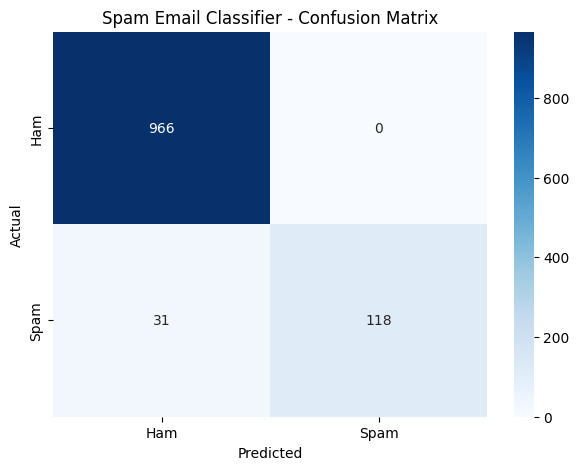

In [10]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Spam Email Classifier - Confusion Matrix")

plt.show()

In [13]:
#Test your own message
def predict_spam(message):
    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "NOT SPAM"


NameError: name 'message' is not defined

In [14]:
message = "Congratulations! You won a free lottery prize. Click now!"

result = predict_spam(message)

print("Message:", message)
print("Prediction:", result)

Message: Congratulations! You won a free lottery prize. Click now!
Prediction: SPAM


In [15]:
#Test several messages
test_messages = [
    "Congratulations! You won a free prize!",
    "Can you call me when you reach home?",
    "URGENT! Claim your cash reward now!",
    "Your meeting is scheduled for tomorrow.",
    "You have won a free vacation. Click here!"
]

for message in test_messages:
    print("Message:", message)
    print("Prediction:", predict_spam(message))
    print("-" * 60)

Message: Congratulations! You won a free prize!
Prediction: SPAM
------------------------------------------------------------
Message: Can you call me when you reach home?
Prediction: NOT SPAM
------------------------------------------------------------
Message: URGENT! Claim your cash reward now!
Prediction: SPAM
------------------------------------------------------------
Message: Your meeting is scheduled for tomorrow.
Prediction: NOT SPAM
------------------------------------------------------------
Message: You have won a free vacation. Click here!
Prediction: NOT SPAM
------------------------------------------------------------


In [16]:
#Save the model
import joblib

joblib.dump(model, "spam_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
